# Quality control and doublet removal: p38α<sup>ΔHPC</sup>

Run cells from top to bottom. Paths, thread limits, and shared annotations are stored with the supporting files in `notebooks/`; embedded plots are retained as visual references from the source analysis.


In [ ]:
# Centralized paths and scheduler-aware thread limits.
repo_root <- if (file.exists("notebooks/paths.R")) "." else if (file.exists("../notebooks/paths.R")) ".." else stop("Run Jupyter from the repository root or notebooks/ directory.")
source(file.path(repo_root, "notebooks", "paths.R"))


25.255 sec elapsed


Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix



29.23 sec elapsed
99.836 sec elapsed
4.149 sec elapsed


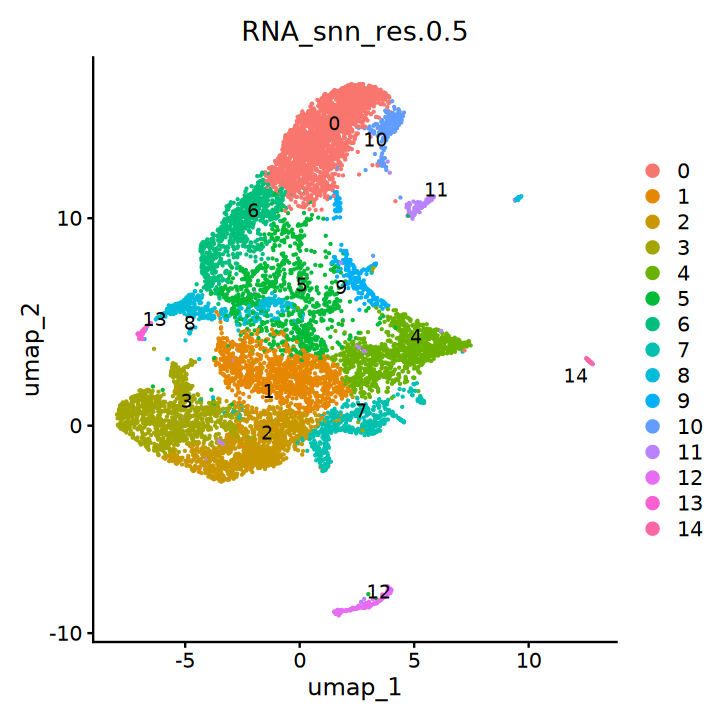

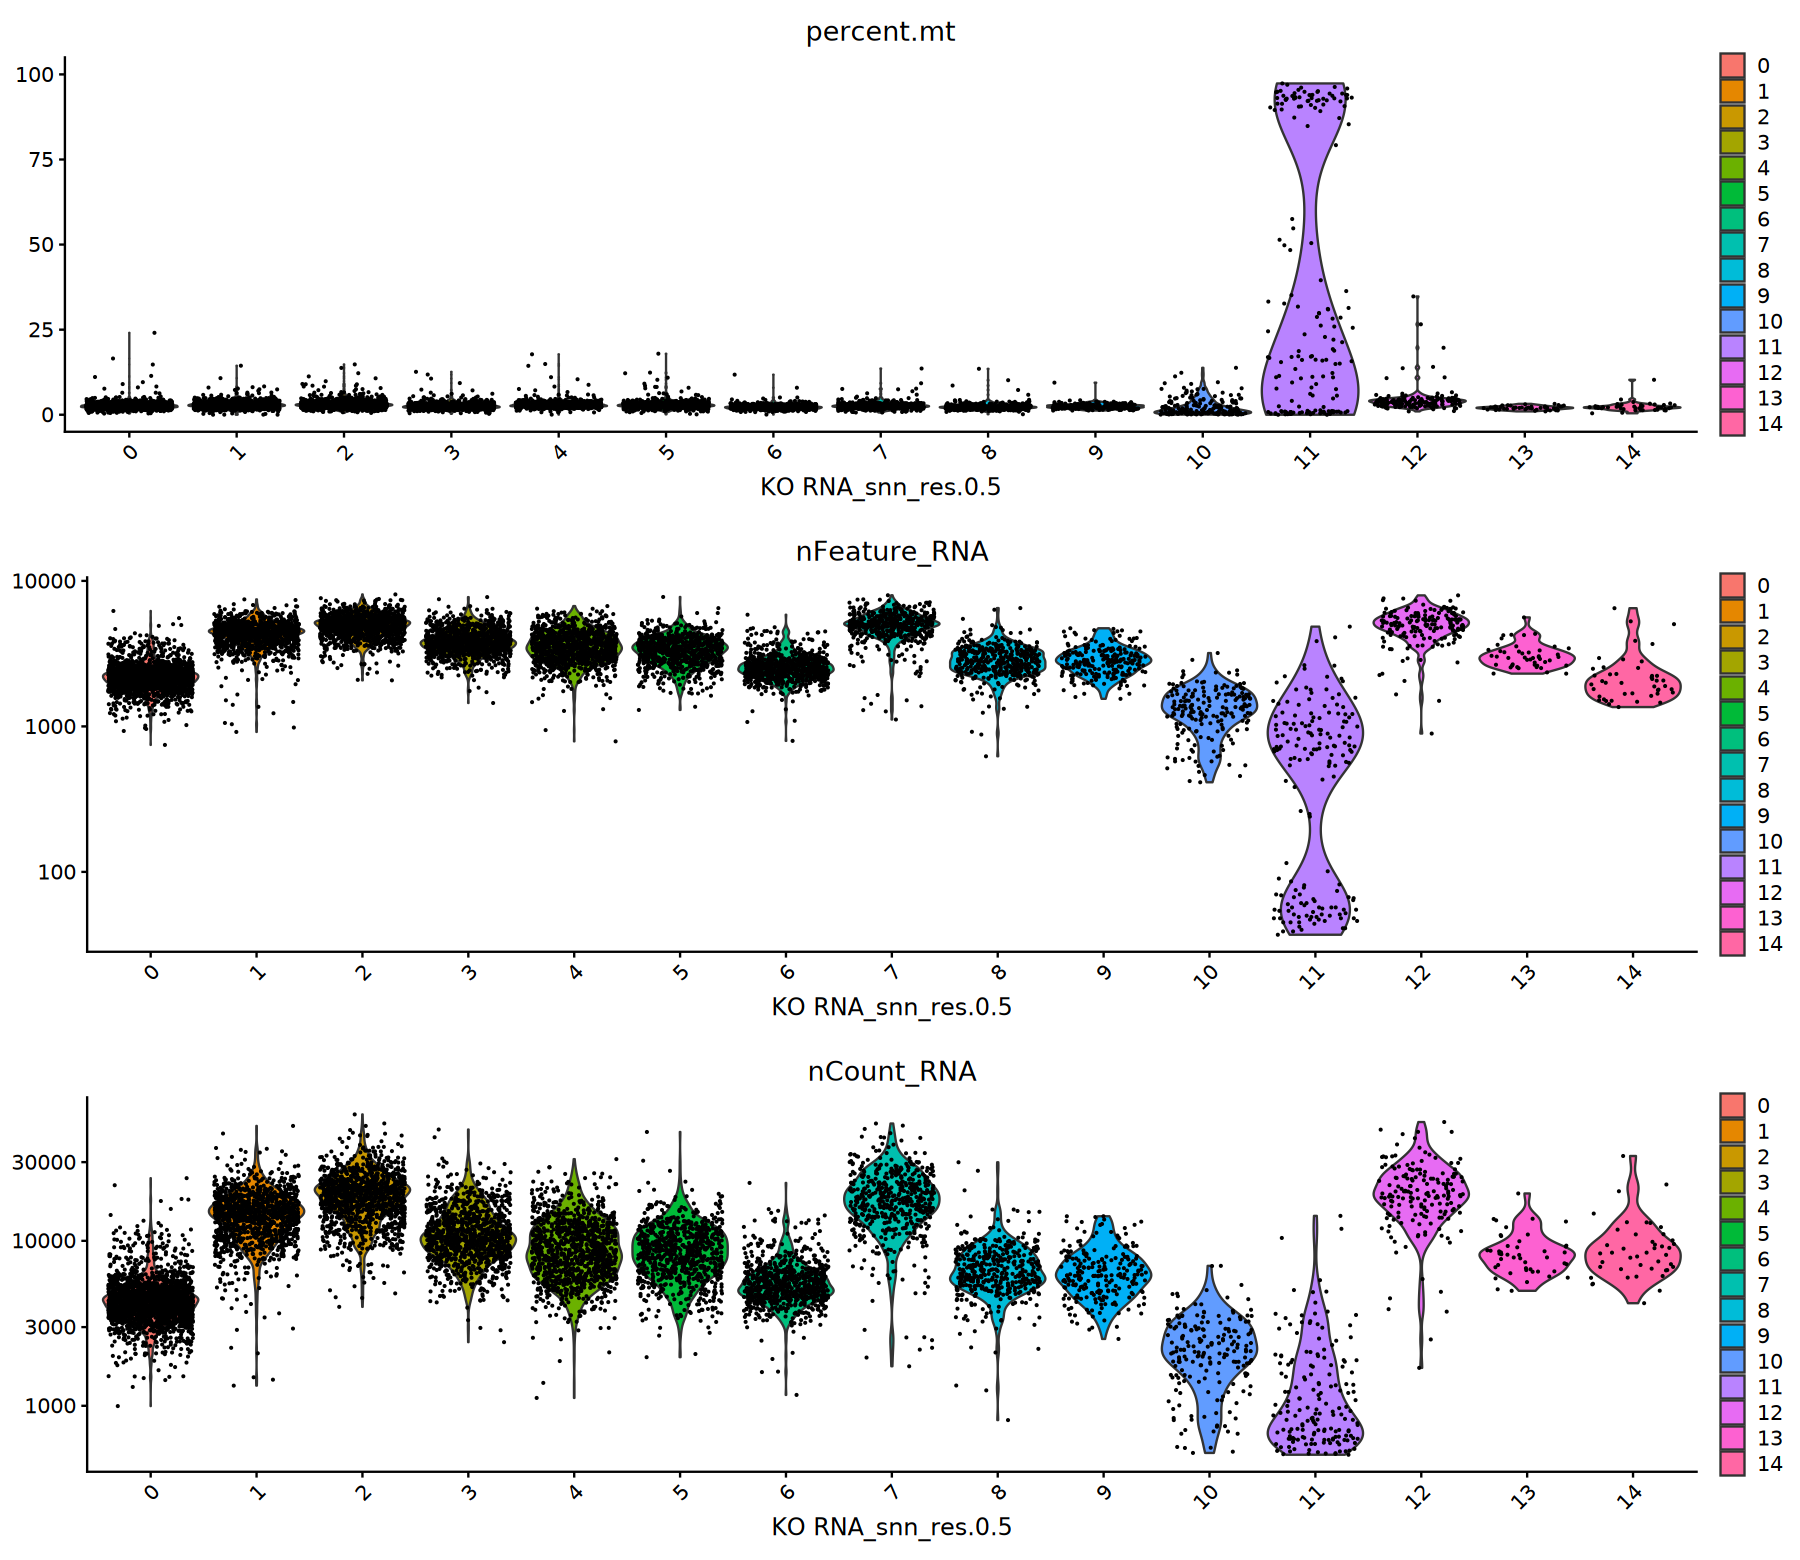

Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix

Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix

Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix

Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix

Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix

Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix



sweep parameters: 707.012 sec elapsed
708.341 sec elapsed


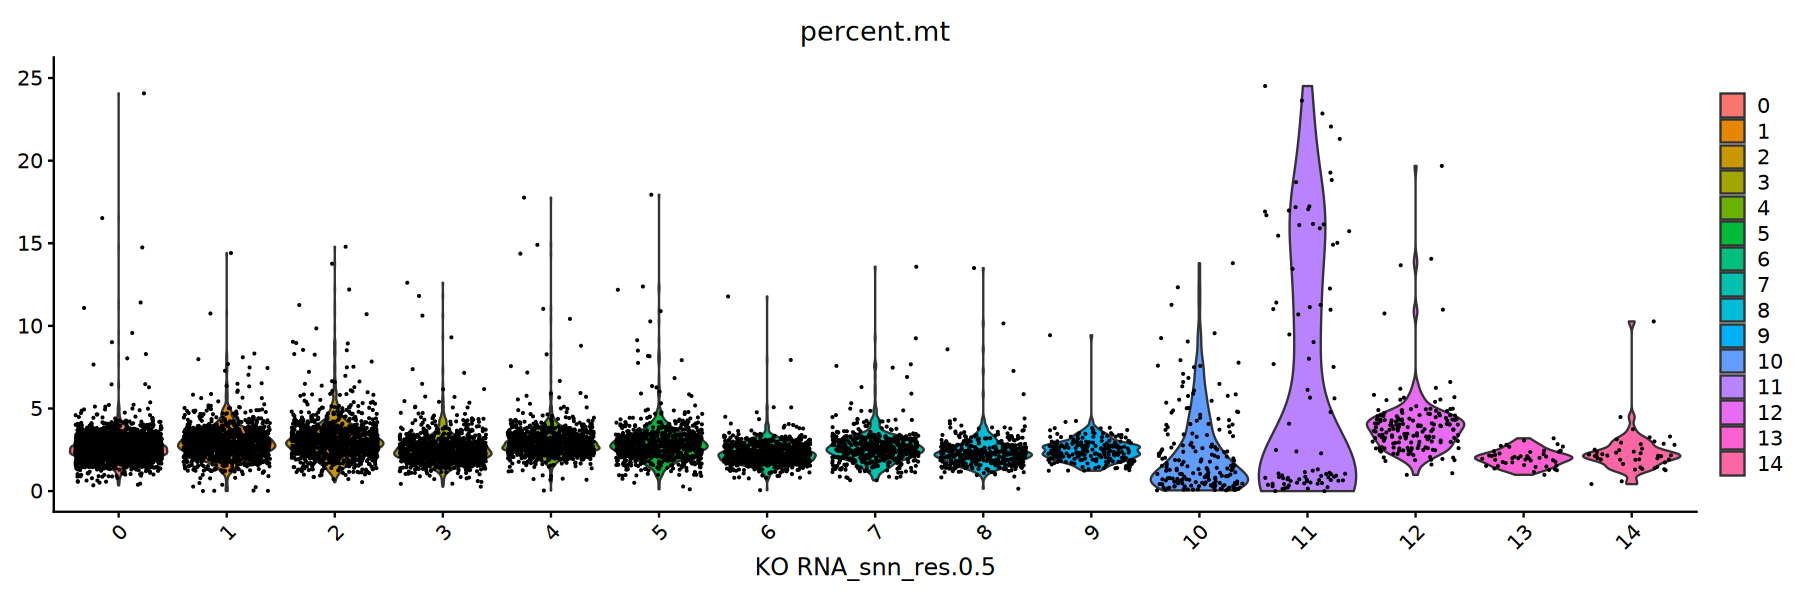

In [1]:
rm(list = ls())
set.seed(1234)
options(future.seed = TRUE)
Sys.setenv(RETICULATE_PYTHON = Sys.getenv("P38_RETICULATE_PYTHON", "/home/gonglihao/miniconda3/envs/42/bin/python"))
suppressPackageStartupMessages({
    library("dplyr")
    library("Matrix")
    library("Seurat")
    library("SeuratWrappers")
    library("future.apply")
    library("tictoc")
    library("ggplot2")
    library("ggpubr")
    library("future")
    library("COSG")
    library("harmony")
    library("parallel")
    library("patchwork")
    library("writexl")
    library("DoubletFinder")
})
source(file.path(repo_root, "notebooks", "doublet_removal.R"))

plan("multicore", workers = p38_workers)
options(future.globals.maxSize = Inf)

path <- upstream_path("cellranger_sh_scripts_and_outputs/KO/KO_cellranger_output/outs/filtered_feature_bc_matrix") 
proj.name <-"KO"

tic()
seu <- CreateSeuratObject(counts = Read10X(data.dir = path), 
                           project = proj.name,
                           min.cells = 3)
seu <- PercentageFeatureSet(seu, pattern = "^mt-", col.name = "percent.mt")
toc()


options(warn=-1)
tic()
seu  <- NormalizeData(seu,  normalization.method="LogNormalize", scale.factor=10000, block.size=800)
seu  <- FindVariableFeatures(seu,  selection.method = "vst", nfeatures = 2000)
plan("sequential")
seu <- ScaleData(seu,  features=rownames(seu), block.size = 1000, min.cells.to.block = 1000)
plan("sequential")
toc()

tic()
seu <- RunPCA(seu, npcs=30, verbose = FALSE)
seu <- RunUMAP(seu, dims = 1:30, umap.method = "umap-learn", metric = "correlation", verbose = FALSE)
toc()

tic()
seu <- FindNeighbors(object = seu, dims = 1:30,verbose=FALSE)
seu <- FindClusters( object = seu, resolution = 0.5, verbose=FALSE)
toc()

options(repr.plot.width=6, repr.plot.height=6)
UMAPPlot(seu, group.by="RNA_snn_res.0.5", label=T,repel=T)

options(repr.plot.width=15, repr.plot.height=13)
Idents(seu)<-"RNA_snn_res.0.5"
group.by<-'RNA_snn_res.0.5'
ggarrange(ncol=1, nrow=3,
VlnPlot(seu, features = "percent.mt", pt.size=0.1,y.max=100, log=F, group.by=group.by)+xlab(paste(proj.name,group.by)),
VlnPlot(seu, features = "nFeature_RNA", pt.size=0.1, log=T, group.by=group.by)+xlab(paste(proj.name,group.by)),
VlnPlot(seu, features = "nCount_RNA", pt.size=0.1, y.max=10000,log=T, group.by=group.by)+xlab(paste(proj.name,group.by)))

options(repr.plot.width=15, repr.plot.height=5)
VlnPlot(seu, features = "percent.mt", pt.size=0.1,y.max=25, log=F, group.by=group.by)+xlab(paste(proj.name,group.by))

seu <-subset(seu, subset=percent.mt< 5 & nFeature_RNA>1000)

options(warn =-1)
tic()
params<-DoubletRemovalParameters(seu, PCs=1:30)
toc()
options(warn =0)

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


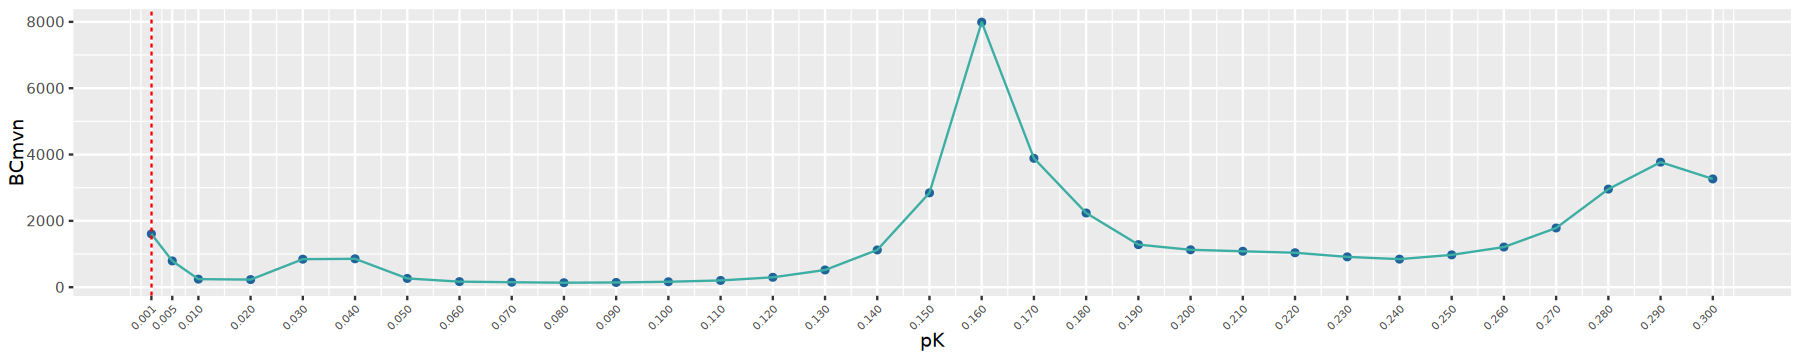

In [2]:
options(repr.plot.wdith=8, repr.plot.height=3)
bcmvnPlot(params$bcmvn, maxpos =0.001)

[1] "Creating 3334 artificial doublets..."
[1] "Creating Seurat object..."
[1] "Normalizing Seurat object..."


Normalizing layer: counts



[1] "Finding variable genes..."


Finding variable features for layer counts



[1] "Scaling data..."


Centering and scaling data matrix



[1] "Running PCA..."
[1] "Calculating PC distance matrix..."
[1] "Computing pANN..."
[1] "Classifying doublets.."
114.732 sec elapsed


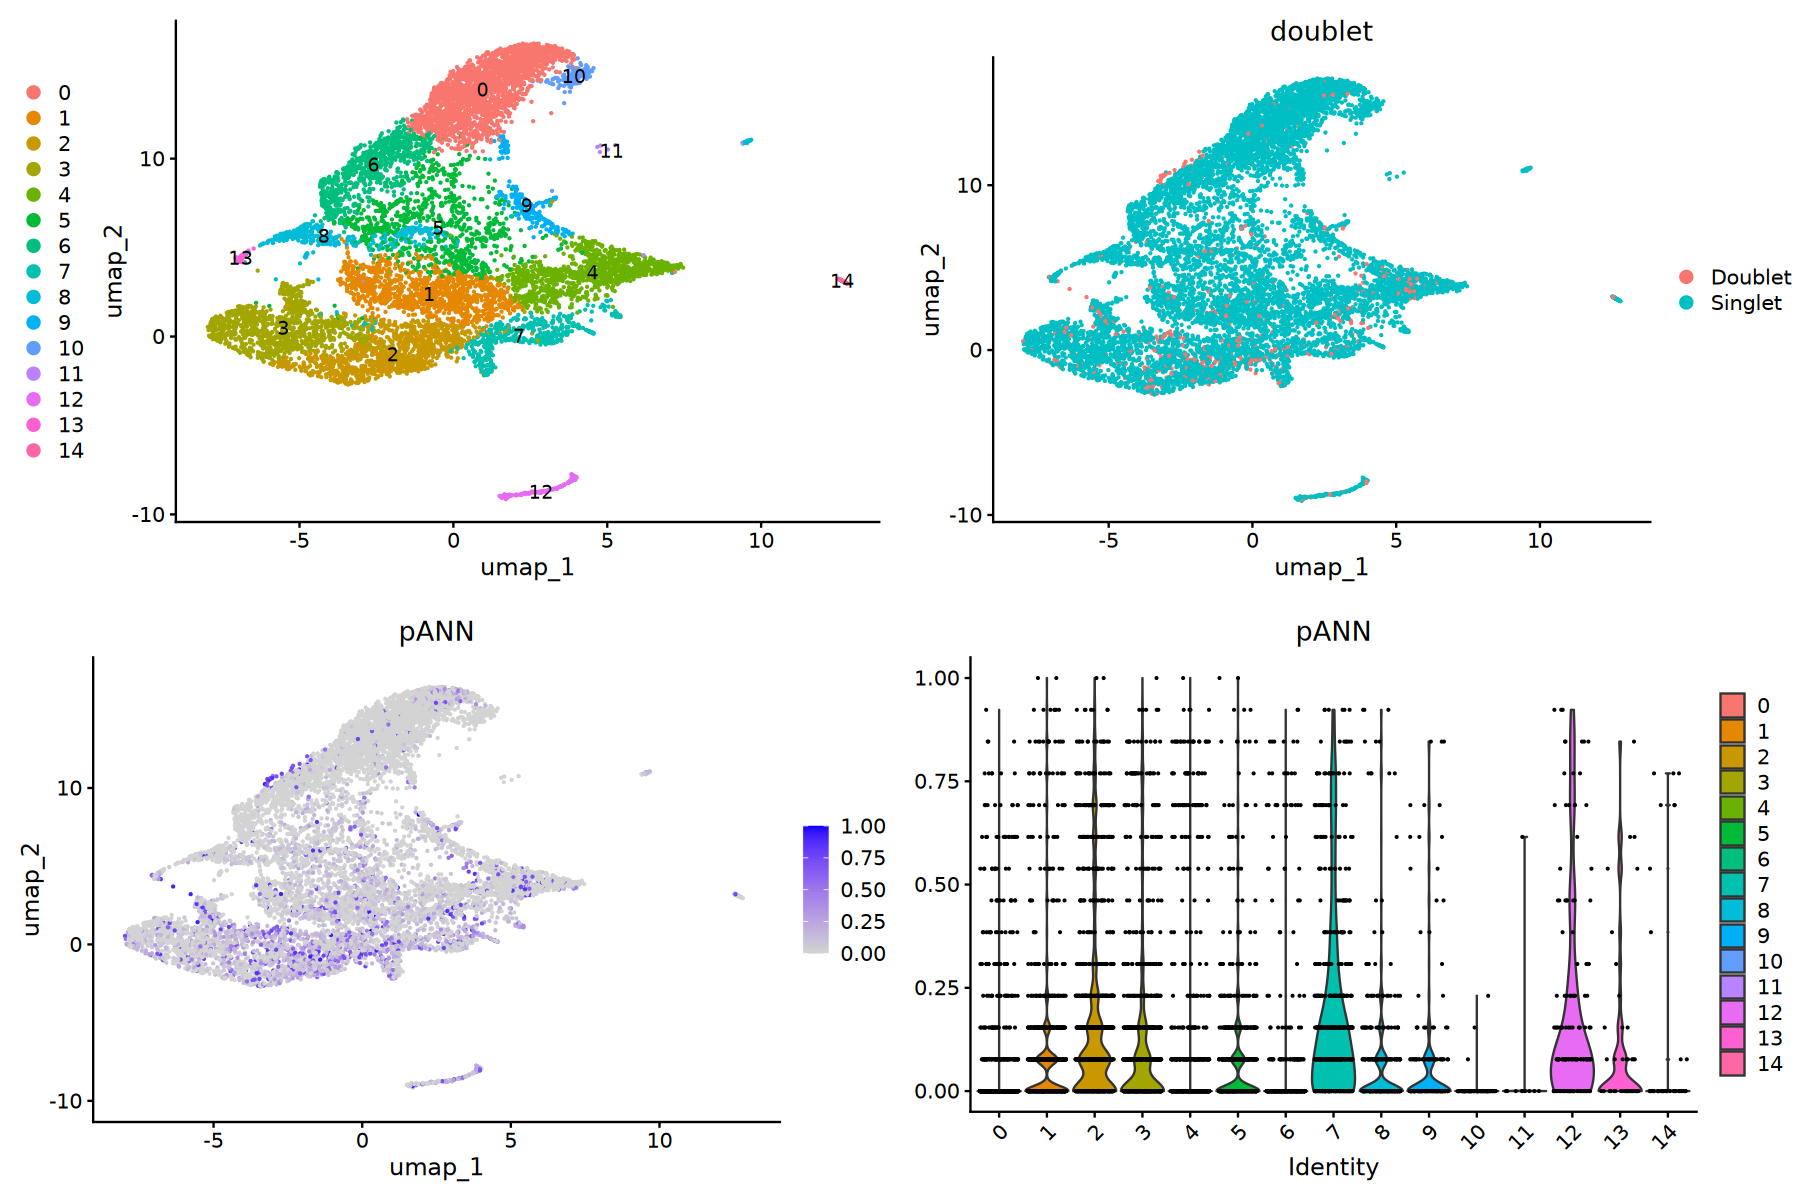

In [3]:
doublet.rate   <- 0.06
annotations    <- seu@meta.data$RNA_snn_res.0.5
homotypic.prop <- modelHomotypic(annotations) 
nExp_poi       <- round(doublet.rate*length(colnames(x = seu)))  ## Assuming 7.5% doublet formation rate - tailor for your dataset
nExp_poi.adj   <- round(nExp_poi*(1-homotypic.prop))

pK <- 0.001

tic()
seu.scored     <- doubletFinder(seu, PCs =1:30, pN = 0.25, pK = pK, nExp = nExp_poi.adj, reuse.pANN = FALSE, sct = FALSE)
toc()

# Run it only once!!! or may cause problem
cname     <- colnames(seu.scored[[]])
DF.name   <- cname[grep('^DF',cname)] 
pANN.name <- cname[grep('^pANN',cname)] 
seu.scored[["doublet"]]<-seu.scored[[DF.name]]
seu.scored[["pANN"]]   <-seu.scored[[pANN.name]]
seu.scored[[DF.name]]  <-NULL
seu.scored[[pANN.name]]<-NULL

options(repr.plot.width=15,repr.plot.height=10)
p1<-DimPlot(seu.scored, reduction = "umap",label=T)+theme(legend.position="left")
p2<-DimPlot(seu.scored, reduction = "umap",group.by="doublet")+theme(legend.position="right")
p3<-FeaturePlot(seu.scored, features = "pANN")
p4<-VlnPlot(seu.scored, features = "pANN", group.by = "RNA_snn_res.0.5",pt.size=0.1)

library(ggpubr)
ggarrange(p1,p2,p3,p4,nrow=2,ncol=2)

seu.singlets <- subset(seu.scored, subset = doublet == "Singlet")

saveRDS(seu.singlets, file=legacy_path("20250509-doublet-p38/1-QC-KO.rds"))